In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.2


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_rdm_dem.csv")
participantcode = data.participant.unique()

data["confidence"] = data["confidence"].astype(theano.config.floatX)

In [1]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_conf=data["confidence"].mean()
sd_conf=data["confidence"].std()

median_conf=data["confidence"].median()

NameError: name 'pd' is not defined

In [13]:
with pm.Model(coords=coords) as hierarchical_model:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_conf, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_conf)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b",0.5)
    

    # Intercept for each county, distributed around group mean mu_a
    # Above we just set mu and sd to a fixed value while here we
    # plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference between basement and floor level
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    confidence_est = a[participant_idx] + b[participant_idx] * data.session.values

    # Data likelihood
    confidence_like = pm.Normal(
        "confidence_like ", mu=confidence_est, sigma=eps, observed=data.confidence, dims="obs_id")
    
    

TypeError: Shared variable constructor needs numeric values and not symbolic variables.

In [6]:
with hierarchical_model:
    hierarchical_trace = pm.sample(20000, tune=2000, target_accept=0.99, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [draws_like_missing, eps, b, a, sigma_b, mu_b, sigma_a, mu_a]


Sampling 2 chains for 2_000 tune and 20_000 draw iterations (4_000 + 40_000 draws total) took 8055 seconds.
There were 11 divergences after tuning. Increase `target_accept` or reparameterize.
The number of effective samples is smaller than 10% for some parameters.


In [ ]:
pm.model_to_graphviz(pm.model_to_graphviz(hierarchical_model))

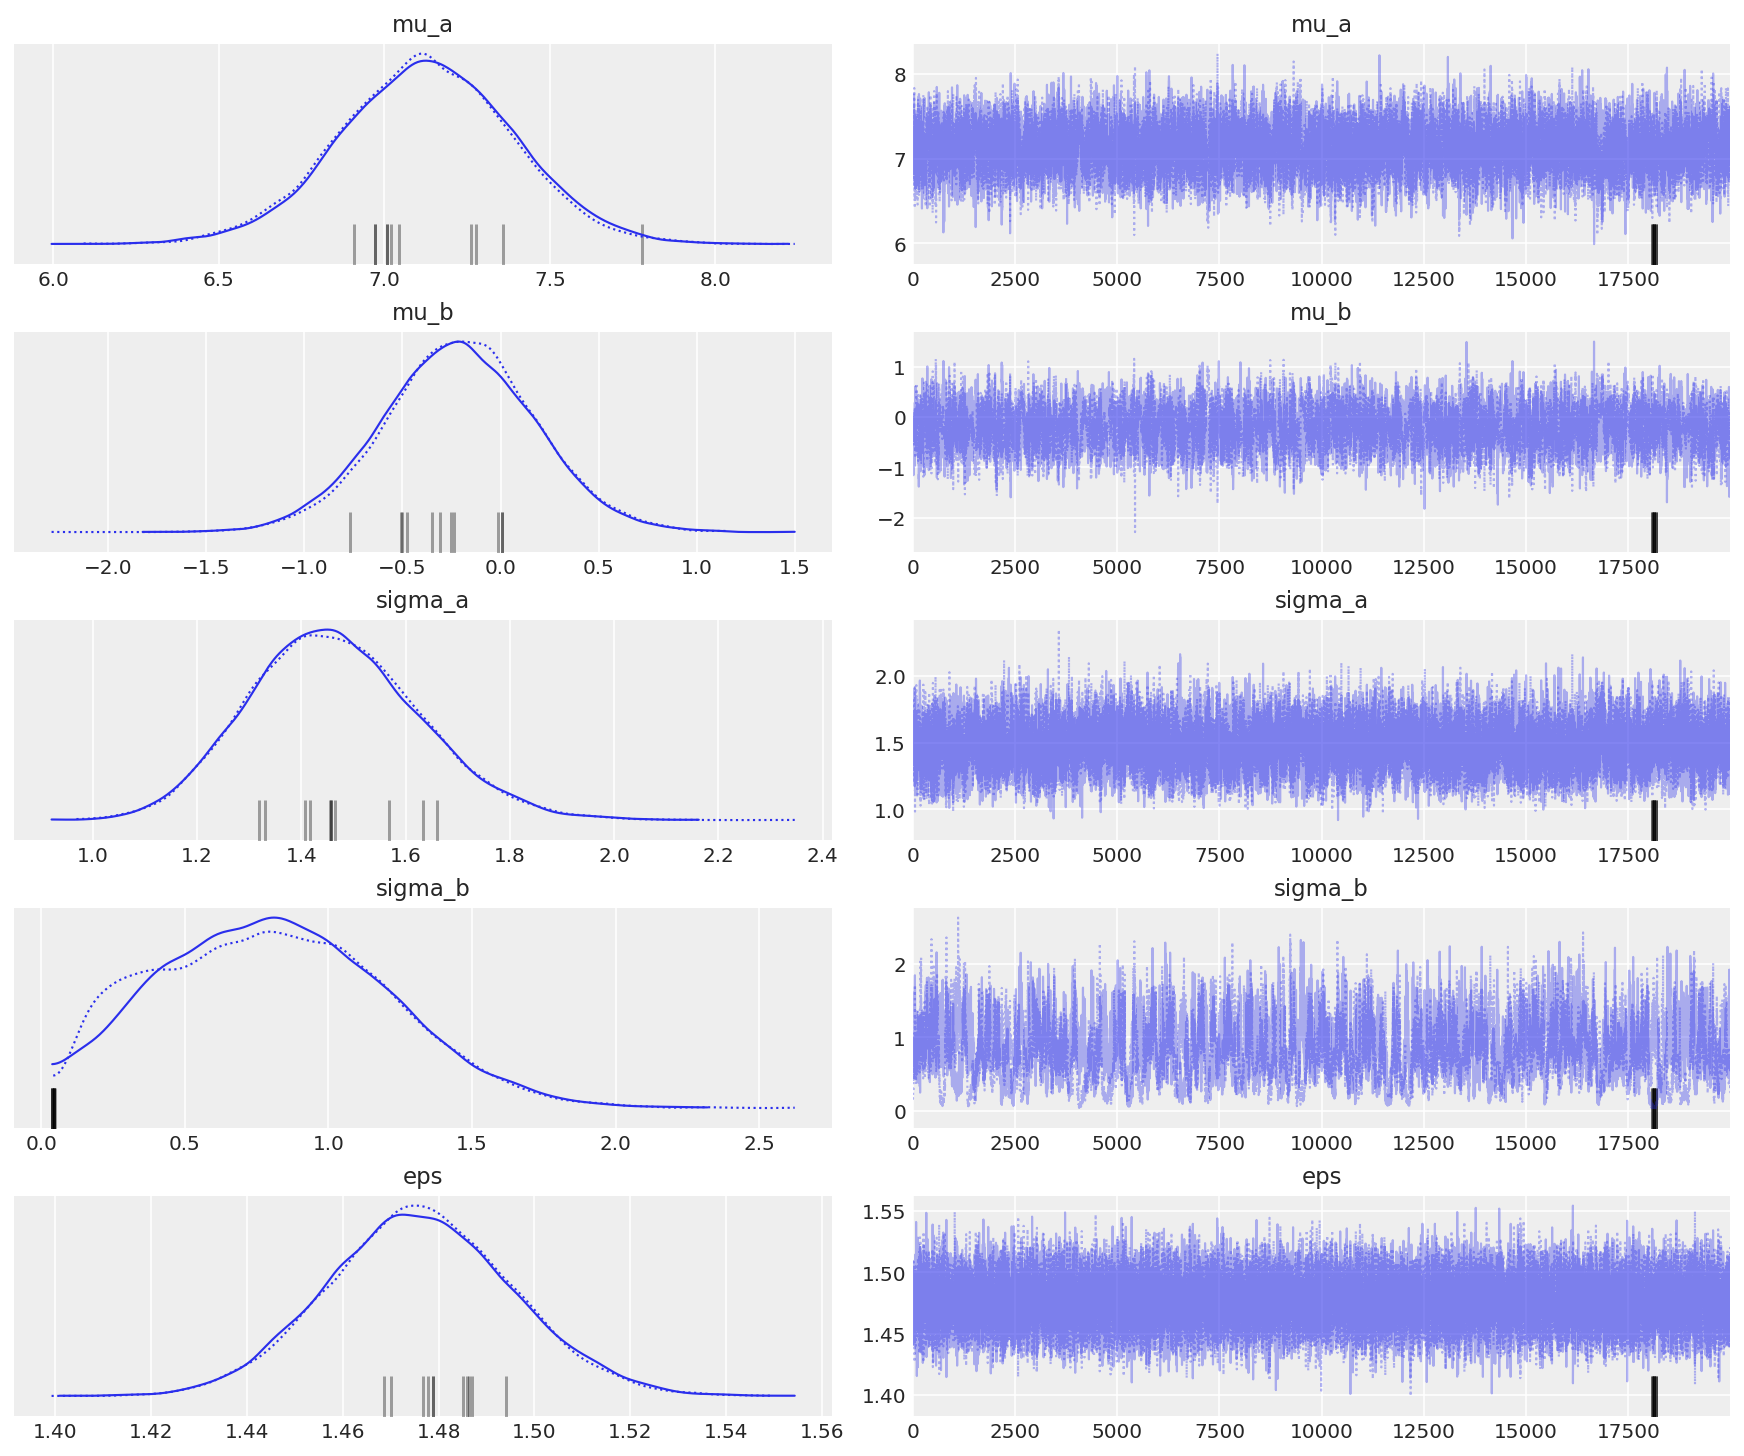

In [7]:
az.plot_trace(hierarchical_trace, var_names=["mu_a", "mu_b", "sigma_a", "sigma_b", "eps"]);


In [ ]:
stat_tms_reg_conf=pm.summary(hierarchical_trace)
stat_tms_reg_conf


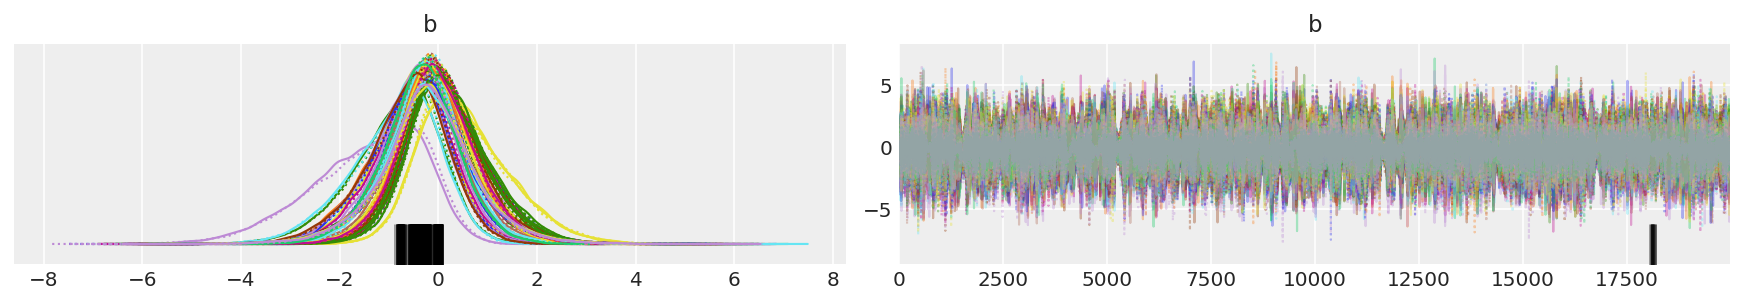

In [12]:
az.plot_trace(hierarchical_trace, var_names=["b"], coords={"participant": participant});


In [ ]:
b_mu_reg_conf=stat_tms_reg_conf.loc['mu_b']['mean']
b_sigma_reg_conf=stat_tms_reg_conf.loc['mu_b']['sd']
print ("Beta TMS =/0") 
b_tms_conf=NormalDist(mu=b_mu_reg_conf, sigma=b_sigma_reg_conf).overlap(NormalDist(mu=0, sigma=b_sigma_reg_conf))
print (b_tms_conf)

In [ ]:
with hierarchical_model:
    ppc_reg = pm.sample_posterior_predictive(
        hierarchical_trace, var_names=["a", "b","draws_like"]
    )

In [ ]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hierarchical_model))